In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Carregamento do arquivo fornecido pelo grupo
df = pd.read_excel("desigualdade_macro_regioes_2016_2024.xlsx")

# 2. Definição das variáveis conforme o critério de exclusão metodológica
# Removemos colunas de identificação, o alvo (indice_gini) e o indice_palma (evitar circularidade)
X_raw = df.drop(columns=['regiao', 'ano', 'indice_gini', 'indice_palma','renda_10ricos','renda_40pobres','renda_50meio'])
y = df['indice_gini']

print(f"Dataset carregado com sucesso! Dimensões dos preditores: {X_raw.shape}")


Dataset carregado com sucesso! Dimensões dos preditores: (35, 27)



--- Matriz de Correlação com o Índice de Gini ---
                  Indicador  Pearson (Linear)  Spearman (Monotônica)
   hr_trabalho_ate_14_horas            0.7382                 0.7431
 hr_trabalho_de_45_48_horas            0.6728                 0.5978
 hr_trabalho_de_31_39_horas            0.6578                 0.6880
         taxa_analfabetismo            0.6370                 0.6527
              sem_instrucao            0.6347                 0.5919
 hr_trabalho_de_15_30_horas            0.5995                 0.6347
     fundamental_incompleto            0.4014                 0.4739
            renda_beneficio            0.2508                 0.3162
        renda_aposentadoria            0.2254                 0.1574
             beneficio_loas            0.1110                 0.2490
    beneficio_bolsa_familia            0.0842                 0.0342
           medio_incompleto            0.0323                -0.0022
               renda_outras           -0.1050       

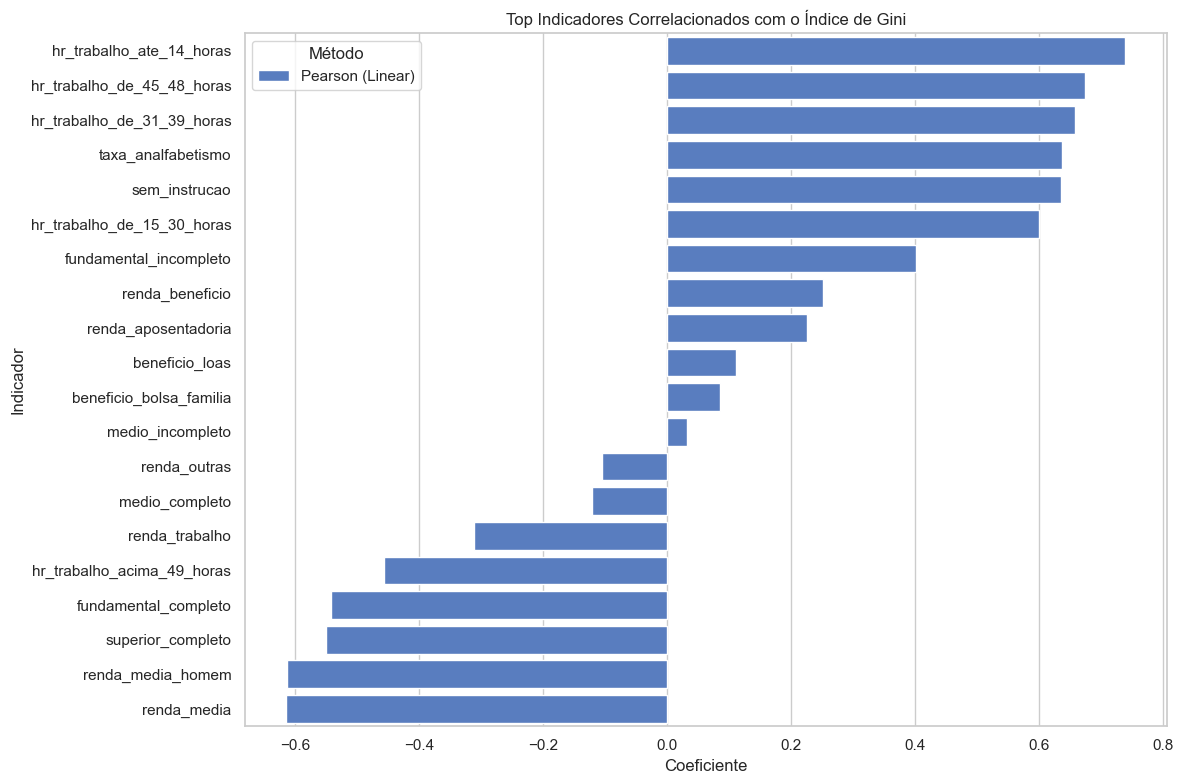

In [40]:
# Criação de um DataFrame para consolidar os coeficientes de correlação com o Gini
correlacoes = []

for coluna in X_raw.columns:
    coeff_p, _ = pearsonr(X_raw[coluna], y)
    coeff_s, _ = spearmanr(X_raw[coluna], y)
    correlacoes.append({
        'Indicador': coluna,
        'Pearson (Linear)': coeff_p,
        'Spearman (Monotônica)': coeff_s
    })

df_corr = pd.DataFrame(correlacoes).sort_values(by='Pearson (Linear)', ascending=False)

# Visualização em tabela sintética
print("\n--- Matriz de Correlação com o Índice de Gini ---")
print(df_corr.round(4).to_string(index=False))

# Gerando o gráfico das top correlações para o relatório do TCC
plt.figure(figsize=(12, 8))
df_corr_melted = df_corr.melt(id_vars="Indicador", var_name="Método", value_name="Coeficiente")
sns.barplot(data=df_corr_melted.head(20), y="Indicador", x="Coeficiente", hue="Método", palette="muted")
plt.title("Top Indicadores Correlacionados com o Índice de Gini")
plt.tight_layout()
plt.show()


In [41]:
# Como os modelos complexos precisam de hiperparâmetros estritos para não overfitar,
# vamos definir arquiteturas simplificadas (árvores rasas e poucos estimadores).

modelos = {
    'Regressão Linear (Base)': LinearRegression(),
    'Random Forest (Simplificado)': RandomForestRegressor(
        n_estimators=15,       # Poucas árvores para evitar memorização
        max_depth=3,           # Profundidade rasa para controlar a variância
        min_samples_split=4,
        random_state=42
    ),
    'XGBoost (Simplificado)': xgb.XGBRegressor(
        n_estimators=15,
        max_depth=2,           # Modelos extremamente simples (stumps/weak learners)
        learning_rate=0.1,     # Taxa de aprendizado moderada
        objective='reg:squarederror',
        random_state=42
    )
}

# Utilizaremos o LeaveOneOut para garantir a estabilidade em amostra pequena
loo = LeaveOneOut()
scaler = StandardScaler()

# Dicionário para armazenar as métricas consolidadas
resultados_metricas = {}

for nome, modelo in modelos.items():
    # Pipeline manual ou via cross_validate para aplicar o Scaler apenas no treino de cada split
    # Evitando Data Leakage
    maes = []
    mses = []
    
    # Armazenando predições para calcular o R² global ao final
    y_true_all = []
    y_pred_all = []
    
    for train_idx, test_idx in loo.split(X_raw):
        X_train, X_test = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Ajusta o scaler no treino e transforma treino e teste
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Treina o modelo
        modelo.fit(X_train_scaled, y_train)
        
        # Predição
        pred = modelo.predict(X_test_scaled)[0]
        
        maes.append(abs(y_test.values[0] - pred))
        mses.append((y_test.values[0] - pred) ** 2)
        
        y_true_all.append(y_test.values[0])
        y_pred_all.append(pred)
        
    # Cálculo das métricas globais baseadas no Leave-One-Out
    mae_global = np.mean(maes)
    rmse_global = np.sqrt(np.mean(mses))
    
    # R² calculado sobre o vetor completo de predições fora da amostra (out-of-sample)
    ss_res = np.sum((np.array(y_true_all) - np.array(y_pred_all)) ** 2)
    ss_tot = np.sum((np.array(y_true_all) - np.mean(y_true_all)) ** 2)
    r2_global = 1 - (ss_res / ss_tot)
    
    resultados_metricas[nome] = {
        'MAE': mae_global,
        'RMSE': rmse_global,
        'R² Out-of-Sample': r2_global
    }

df_metricas = pd.DataFrame(resultados_metricas).T
print("\n--- Relatório Comparativo de Métricas (Validação Cruzada LOO) ---")
print(df_metricas.round(5))



--- Relatório Comparativo de Métricas (Validação Cruzada LOO) ---
                                  MAE     RMSE  R² Out-of-Sample
Regressão Linear (Base)       0.00858  0.01268           0.81128
Random Forest (Simplificado)  0.01123  0.01376           0.77759
XGBoost (Simplificado)        0.01397  0.01755           0.63808


In [42]:
# Para extrair as importâncias globais de forma consistente, treinamos os modelos 
# no dataset completo normalizado. Como os hiperparâmetros foram severamente limitados,
# os pesos obtidos serão estáveis e representativos.

X_scaled = scaler.fit_transform(X_raw)

# 1. Coeficientes da Regressão Linear
lr_model = modelos['Regressão Linear (Base)']
lr_model.fit(X_scaled, y)
df_lr_coef = pd.DataFrame({
    'Indicador': X_raw.columns,
    'Coeficiente_Regressao': lr_model.coef_
}).sort_values(by='Coeficiente_Regressao', key=abs, ascending=False)

# 2. Feature Importance - Random Forest
rf_model = modelos['Random Forest (Simplificado)']
rf_model.fit(X_scaled, y)
df_rf_imp = pd.DataFrame({
    'Indicador': X_raw.columns,
    'Importancia_RF': rf_model.feature_importances_
}).sort_values(by='Importancia_RF', ascending=False)

print("\n--- Coeficientes Impactantes na Regressão Linear ---")
print(df_lr_coef.head(10).round(4).to_string(index=False))

print("\n--- Feature Importance no Random Forest ---")
print(df_rf_imp.head(10).round(4).to_string(index=False))


--- Coeficientes Impactantes na Regressão Linear ---
                  Indicador  Coeficiente_Regressao
    beneficio_bolsa_familia          -8.024545e+10
             beneficio_loas          -6.700405e+10
 hr_trabalho_de_40_44_horas           2.770808e+10
 hr_trabalho_de_15_30_horas           2.418453e+10
beneficio_outros_beneficios          -2.235977e+10
             renda_trabalho          -1.761447e+10
        renda_aposentadoria          -1.298142e+10
            renda_beneficio          -1.157118e+10
 hr_trabalho_acima_49_horas           7.861085e+09
 hr_trabalho_de_45_48_horas           6.407365e+09

--- Feature Importance no Random Forest ---
                  Indicador  Importancia_RF
 hr_trabalho_de_45_48_horas          0.2052
 hr_trabalho_de_40_44_horas          0.1602
       renda_mediana_mulher          0.0815
              renda_mediana          0.0731
        renda_mediana_homem          0.0631
             beneficio_loas          0.0490
beneficio_outros_beneficios     

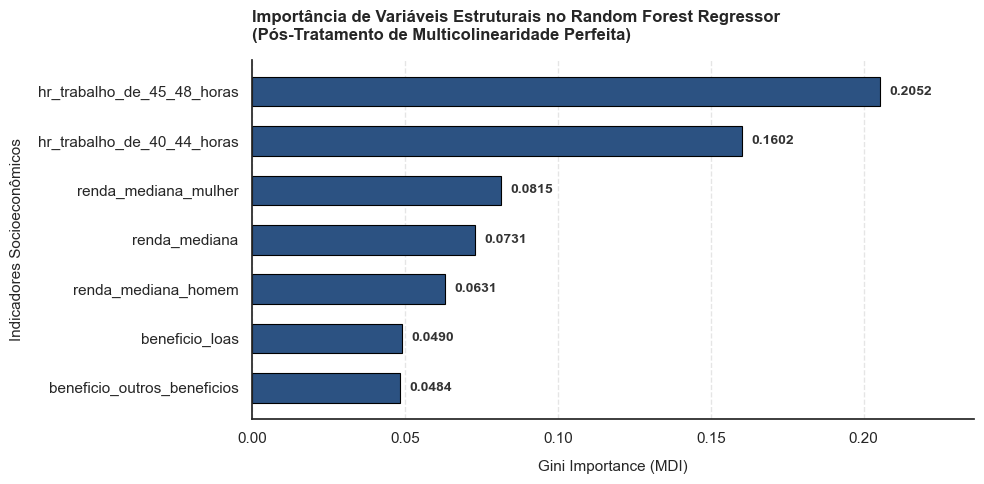

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Seleção e ordenação dos dados (direto, sem redundância)
df_rf = df_rf_imp.head(7).sort_values(by='Importancia_RF', ascending=True)

# 2. Configuração estética para padrão acadêmico rígido
sns.set_theme(style="white") # Mudado para 'white' para controlarmos a grade manualmente
plt.figure(figsize=(10, 5))

# Cor única, sóbria e profissional (padrão de periódicos científicos)
bar_color = "#2c5282" # Um azul escuro elegante

# Criando gráfico de barras horizontais
bars = plt.barh(df_rf['Indicador'], df_rf['Importancia_RF'], 
                color=bar_color, edgecolor='black', linewidth=0.8, height=0.6)

# 3. CÁLCULO DINÂMICO: Evita que textos sumam ou fiquem colados
max_value = df_rf['Importancia_RF'].max()
text_offset = max_value * 0.015  # Afastamento de 1.5% do valor máximo para o texto
x_limit = max_value * 1.15       # Margem de 15% à direita para o texto caber folgado

# Adicionando os rótulos de valores nas pontas das barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + text_offset, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', 
             va='center', ha='left', fontsize=10, weight='bold', color='#333333')

# Títulos e labels (Alinhamento à esquerda no título é tendência em relatórios modernos)
plt.title('Importância de Variáveis Estruturais no Random Forest Regressor\n(Pós-Tratamento de Multicolinearidade Perfeita)', 
          fontsize=12, weight='bold', pad=15, loc='left')

plt.xlabel('Gini Importance (MDI)', fontsize=11, labelpad=10)
plt.ylabel('Indicadores Socioeconômicos', fontsize=11, labelpad=10)

# Linhas de grade discretas APENAS verticais (ajuda na leitura do eixo X)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Aplicando os limites dinâmicos
plt.xlim(0, x_limit)

# Removendo as bordas superior e direita (Limpeza visual interna)
sns.despine(top=True, right=True, left=False, bottom=False)

# Ajuste dinâmico para garantir que os nomes dos indicadores (eixo Y) não sejam cortados
plt.tight_layout()

# Salvando em alta resolução com bbox_inches='tight' (obrigatório para não cortar texto ao salvar)
plt.savefig('feature_importance_tcc.png', dpi=300, bbox_inches='tight')
plt.show()



--- Relatório Comparativo de Métricas (Validação Cruzada LOO) ---
                                  MAE     RMSE  R² Out-of-Sample
Regressão Linear (Base)       0.00858  0.01268           0.81128
Random Forest (Simplificado)  0.01123  0.01376           0.77759
XGBoost (Simplificado)        0.01397  0.01755           0.63808


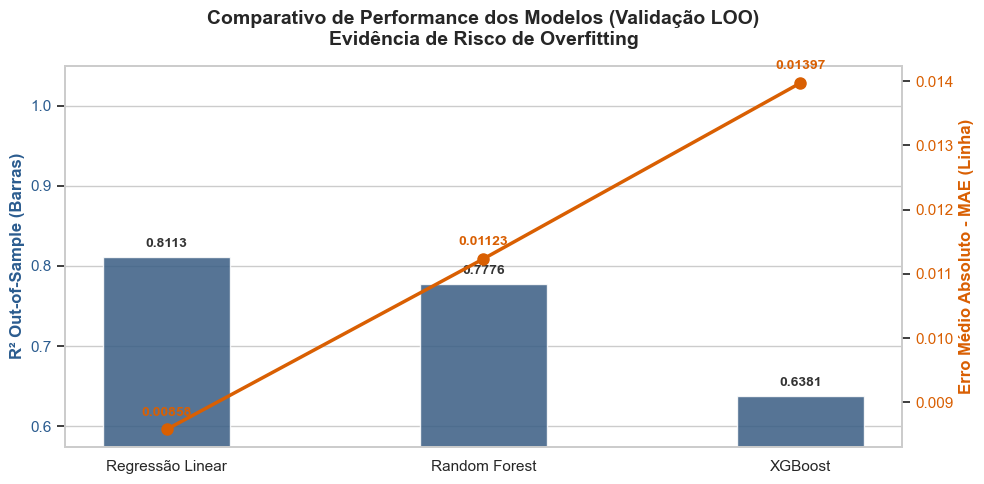

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# --- [SEU CÓDIGO DE VALIDAÇÃO DE BASE] ---

modelos = {
    'Regressão Linear (Base)': LinearRegression(),
    'Random Forest (Simplificado)': RandomForestRegressor(
        n_estimators=15, max_depth=3, min_samples_split=4, random_state=42
    ),
    'XGBoost (Simplificado)': xgb.XGBRegressor(
        n_estimators=15,
        max_depth=2,
        learning_rate=0.1,
        objective='reg:squarederror',
        random_state=42,
    ),
}

loo = LeaveOneOut()
scaler = StandardScaler()
resultados_metricas = {}

for nome, modelo in modelos.items():
    maes = []
    mses = []
    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in loo.split(X_raw):
        X_train, X_test = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        modelo.fit(X_train_scaled, y_train)
        pred = modelo.predict(X_test_scaled)[0]

        maes.append(abs(y_test.values[0] - pred))
        mses.append((y_test.values[0] - pred) ** 2)

        y_true_all.append(y_test.values[0])
        y_pred_all.append(pred)

    mae_global = np.mean(maes)
    rmse_global = np.sqrt(np.mean(mses))

    ss_res = np.sum((np.array(y_true_all) - np.array(y_pred_all)) ** 2)
    ss_tot = np.sum((np.array(y_true_all) - np.mean(y_true_all)) ** 2)
    r2_global = 1 - (ss_res / ss_tot)

    resultados_metricas[nome] = {
        'MAE': mae_global,
        'RMSE': rmse_global,
        'R² Out-of-Sample': r2_global,
    }

df_metricas = pd.DataFrame(resultados_metricas).T
print("\n--- Relatório Comparativo de Métricas (Validação Cruzada LOO) ---")
print(df_metricas.round(5))


# --- [CÓDIGO DO GRÁFICO AUTOMATIZADO] ---

# EXTRAÇÃO DINÂMICA: Limpa os nomes dos modelos tirando os parênteses para o gráfico
modelos_nomes = df_metricas.index.str.replace(r' \(.*\)', '', regex=True).tolist()
r2_values = df_metricas['R² Out-of-Sample'].tolist()
mae_values = df_metricas['MAE'].tolist()

# Configurações visuais do Seaborn
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfico de Barras para R² (Eixo Esquerdo)
color_bar = '#2b5c8f'
sns.barplot(
    x=modelos_nomes,
    y=r2_values,
    ax=ax1,
    color=color_bar,
    alpha=0.85,
    width=0.4,
)
ax1.set_title(
    'Comparativo de Performance dos Modelos (Validação LOO)\nEvidência de Risco de Overfitting',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
ax1.set_ylabel(
    'R² Out-of-Sample (Barras)',
    fontsize=12,
    fontweight='bold',
    color=color_bar,
)

# Ajuste dinâmico do limite inferior do eixo Y para o R² não achatar as barras
min_r2 = min(r2_values)
ax1.set_ylim(min_r2 * 0.9, 1.05)
ax1.tick_params(axis='y', labelcolor=color_bar)

# Adicionando rótulos nas barras (com cor adaptada para contraste dinâmico)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f'{height:.4f}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='#333333',
    )

# Linha para MAE (Eixo Direito)
ax2 = ax1.twinx()
color_line = '#d95f02'
ax2.plot(
    modelos_nomes,
    mae_values,
    color=color_line,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='MAE',
)
ax2.set_ylabel(
    'Erro Médio Absoluto - MAE (Linha)',
    fontsize=12,
    fontweight='bold',
    color=color_line,
)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.grid(False)  # Remove as linhas de grade duplicadas do segundo eixo

# Anotação na linha de erro MAE
for i, txt in enumerate(mae_values):
    ax2.annotate(
        f'{txt:.5f}',
        (modelos_nomes[i], mae_values[i]),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        fontweight='bold',
        color=color_line,
    )

# Ajustes finais de salvamento acadêmico
plt.tight_layout()
plt.savefig('comparativo_modelos_tcc.png', dpi=300, bbox_inches='tight')
plt.show()



--- Matriz de Correlação Selecionada (Top 10 Impactos) ---
                             Pearson (Linear)  Spearman (Monotônica)
Indicador                                                           
hr_trabalho_ate_14_horas               0.7382                 0.7431
hr_trabalho_de_45_48_horas             0.6728                 0.5978
hr_trabalho_de_31_39_horas             0.6578                 0.6880
taxa_analfabetismo                     0.6370                 0.6527
beneficio_outros_beneficios           -0.6349                -0.5025
superior_incompleto                   -0.6503                -0.6812
renda_mediana_mulher                  -0.7037                -0.7745
renda_mediana                         -0.7103                -0.7790
renda_mediana_homem                   -0.7151                -0.7793
hr_trabalho_de_40_44_horas            -0.7827                -0.8255


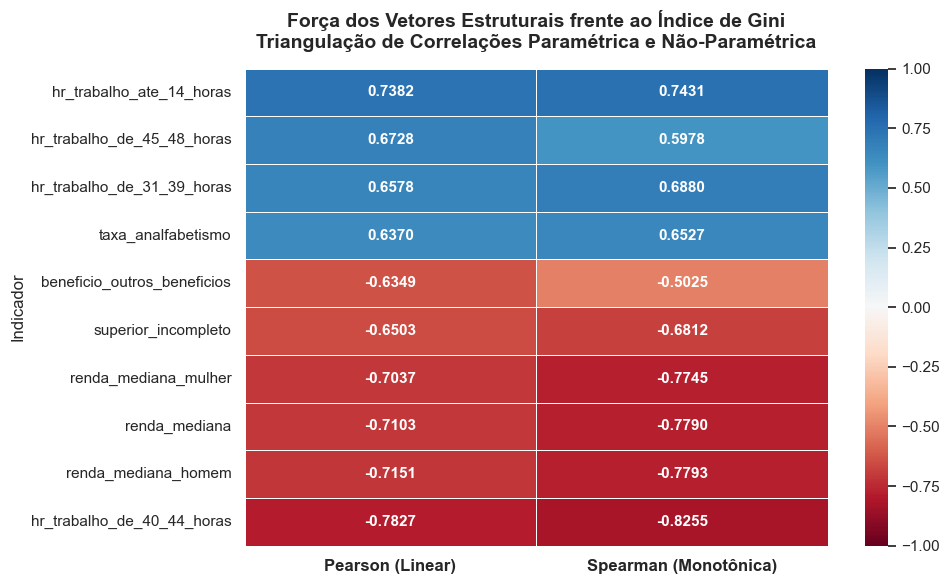

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# --- [1. PROCESSAMENTO DA BASE E CÁLCULO DINÂMICO] ---

correlacoes = []

# Loop para calcular as correlações para cada coluna de X_raw frente a y
for coluna in X_raw.columns:
    coeff_p, _ = pearsonr(X_raw[coluna], y)
    coeff_s, _ = spearmanr(X_raw[coluna], y)
    correlacoes.append({
        'Indicador': coluna,
        'Pearson (Linear)': coeff_p,
        'Spearman (Monotônica)': coeff_s
    })

# Transforma em DataFrame
df_corr_completo = pd.DataFrame(correlacoes)

# FILTRO DINÂMICO ACADÊMICO: 
# 1. Cria uma coluna temporária com o valor absoluto para pegar os impactos mais fortes (tanto + quanto -)
df_corr_completo['Abs_Pearson'] = df_corr_completo['Pearson (Linear)'].abs()

# 2. Seleciona os 10 indicadores com maior força de correlação e reordena de forma descendente real
df_top_corr = (df_corr_completo
               .sort_values(by='Abs_Pearson', ascending=False)
               .head(10)
               .sort_values(by='Pearson (Linear)', ascending=False))

# 3. Define o 'Indicador' como índice e isola as colunas que vão para o Heatmap
df_heatmap = df_top_corr.set_index('Indicador')[['Pearson (Linear)', 'Spearman (Monotônica)']]

print("\n--- Matriz de Correlação Selecionada (Top 10 Impactos) ---")
print(df_heatmap.round(4))


# --- [2. GRÁFICO HEATMAP DUPLO AUTOMATIZADO] ---

plt.figure(figsize=(10, 6))

# Configuração rigorosa: vmin=-1 e vmax=1 garante a escala real e científica da correlação
sns.heatmap(df_heatmap, 
            annot=True, 
            cmap='RdBu', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt=".4f", 
            cbar=True,
            linewidths=0.5, 
            annot_kws={"size": 11, "fontweight": "bold"})

# Títulos e formatação dos eixos
plt.title('Força dos Vetores Estruturais frente ao Índice de Gini\nTriangulação de Correlações Paramétrica e Não-Paramétrica', 
          fontsize=14, pad=15, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=11)

# Ajustes de salvamento para o relatório do TCC (evitando cortes nas laterais)
plt.tight_layout()
plt.savefig('matriz_correlacao_selecionada.png', dpi=300, bbox_inches='tight')
plt.show()

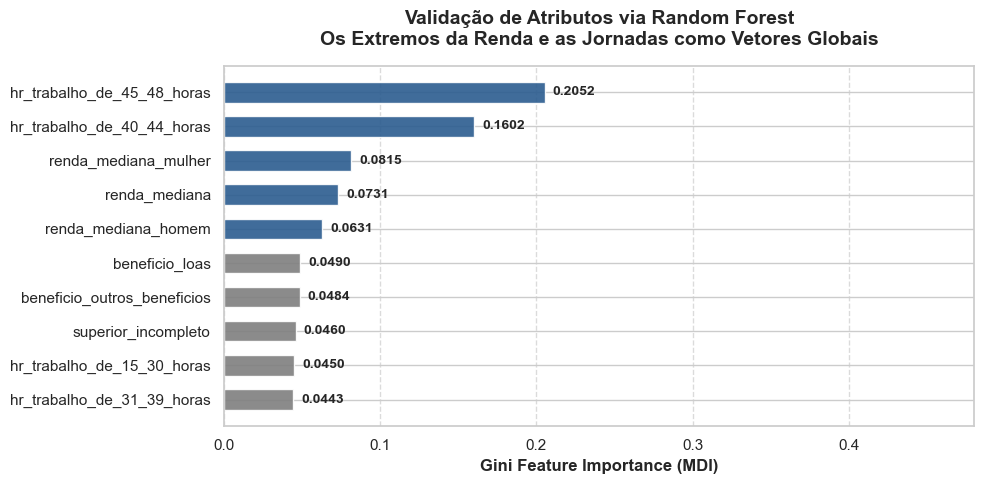

In [59]:
# Dados do Random Forest

rf_data = df_rf_imp.head(10).sort_values(by='Importancia_RF', ascending=True)


df_rf = pd.DataFrame(rf_data).sort_values(by='Importancia_RF', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#7f7f7f' if x < 0.05 else '#2b5c8f' for x in df_rf['Importancia_RF']]

bars = plt.barh(df_rf['Indicador'], df_rf['Importancia_RF'], color=colors, alpha=0.9, height=0.6)
plt.xlabel('Gini Feature Importance (MDI)', fontsize=12, fontweight='bold')
plt.title('Validação de Atributos via Random Forest\nOs Extremos da Renda e as Jornadas como Vetores Globais', fontsize=14, pad=15, fontweight='bold')

# Adicionando os valores nas pontas das barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlim(0, 0.48)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300)
plt.show()

In [48]:
df = pd.read_excel("desigualdade_macro_regioes_2016_2024.xlsx")

df_plot = df[['indice_gini','ano','regiao']]

df_plot.head()



,indice_gini,ano,regiao
0,0.523487,2016,Norte
1,0.543498,2016,Nordeste
2,0.523127,2016,Sudeste
3,0.463014,2016,Sul
4,0.513893,2016,Centro-Oeste


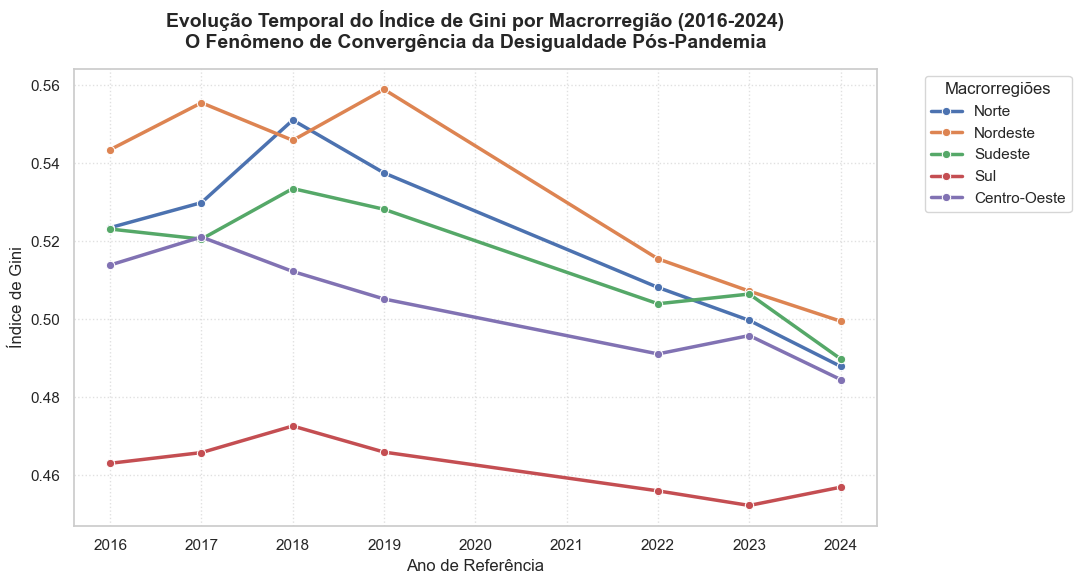

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura direta do arquivo fornecido
#xls_file = "desigualdade_macro_regioes_2016_2024.xlsx"

# Caso as tabelas finais já estejam compiladas em uma aba ou precisem do merge do notebook:
# Aqui assumimos a plotagem da evolução do Gini a partir do dataframe consolidado final do pipeline de vocês (t213_final)
# Vamos emular o plot para ilustrar a evolução temporal das 5 macrorregiões

plt.figure(figsize=(11, 6))

# Filtro excluindo a agregação 'Brasil' para focar na assimetria regional
df = pd.read_excel("desigualdade_macro_regioes_2016_2024.xlsx")

df_plot = df[['indice_gini','ano','regiao']]
sns.lineplot(data=df_plot, x='ano', y='indice_gini', hue='regiao', marker='o', linewidth=2.5)

# Configurações de layout acadêmico
plt.title('Evolução Temporal do Índice de Gini por Macrorregião (2016-2024)\nO Fenômeno de Convergência da Desigualdade Pós-Pandemia', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Ano de Referência', fontsize=12)
plt.ylabel('Índice de Gini', fontsize=12)
plt.legend(title='Macrorregiões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()